Mini-project: predict appartment prices from size

Simple single feature linear regression:

$\mathrm{price} = w * \mathrm{size} + b$

Generate fake housing data:

In [28]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42) # reproduceable results

m = 120 # sample size
X = 20 + 80 * np.random.rand(m) # size between 20 and 100 square meters
y = 5000 + 3000 * X + np.random.randn(m) * 20000

Text(0, 0.5, 'Price (USD)')

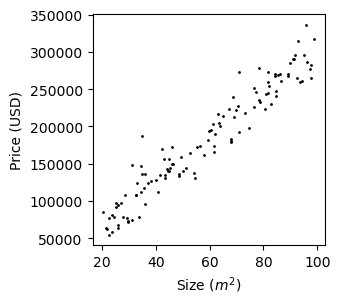

In [29]:
f, ax = plt.subplots(1,1, figsize=(3,3))
ax.scatter(X, y, marker='o', s=1, color='black')
ax.set_xlabel('Size ($m^2$)')
ax.set_ylabel('Price (USD)')

Define cost function:
\begin{equation*}
J(w,b) = \frac{1}{2m} \sum_{i=1}^m \left( \hat{y}^i - y^i \right)^2 = \frac{1}{2m} \sum_{i=1}^m \left( w x^i + b - y^i \right)^2
\end{equation*}

In [30]:
def cost(w, b, x, y):
    yhat = w * x + b
    return np.mean((yhat - y)**2)/2

Derive derivatives for gradient descent:

\begin{equation*}
\frac{\partial}{\partial w} J(w,b) = \frac{1}{m} \sum_{i=1}^m \left( w x^i + b - y^i \right)x^i = \frac{1}{m} \sum_{i=1}^m \left( \hat{y}^i - y^i \right)x^i
\end{equation*}

by using $\frac{d}{dw} (f^2) = 2ff'$ with $f = wx^i+b-y^i$ and $f' = x^i$ ; and:

\begin{equation*}
\frac{\partial}{\partial b} J(w,b) = \frac{1}{m} \sum_{i=1}^m \left( w x^i + b - y^i \right) = \frac{1}{m} \sum_{i=1}^m \left( \hat{y}^i - y^i \right)
\end{equation*}

with the same logic and $f' = 1$



In [31]:
def gradients(w, b, x, y):
    yhat = w * x + b
    dw = np.mean((yhat - y)*x)
    db = np.mean(yhat - y)
    return dw, db

Gradient descent loop:

In [42]:
# standardize X
X_mean, X_std = X.mean(), X.std()
Xs = (X - X_mean)/X_std

w, b = 0., 0.
lr = 0.01
n_steps = 400

loss_history = []

for step in range(n_steps):
    # first get the gradients
    dw, db = gradients(w, b, Xs, y)
    # then update the w and b parameters
    w -= lr * dw
    b -= lr * db
    loss_history.append(cost(w, b, Xs, y))

Learning curve plot:

Text(0, 0.5, 'Loss (cost)')

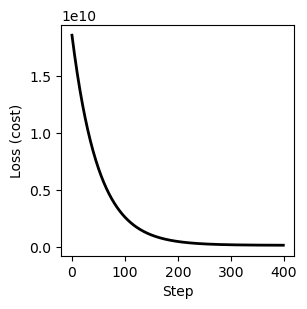

In [43]:
f, ax = plt.subplots(1,1, figsize=(3,3))
ax.plot(loss_history, lw=2, color='black')
ax.set_xlabel("Step")
ax.set_ylabel('Loss (cost)')

Finally plot the fitted line:

Text(0, 0.5, 'Price (USD)')

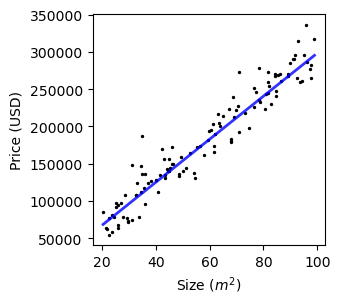

In [46]:
X_line = np.linspace(X.min(), X.max(), 200)
Xs_line = (X_line - X_mean)/X_std
y_line = w * Xs_line + b

f, ax = plt.subplots(1,1, figsize=(3,3))
ax.scatter(X, y, s=2, color='black')
ax.plot(X_line, y_line, lw=2, color='blue', alpha=0.8)
ax.set_xlabel('Size ($m^2$)')
ax.set_ylabel('Price (USD)')